In [ ]:
import os
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CONFIGURATION
# ============================================================================

# Output directory - CHANGE THIS TO WHERE YOU WANT FILES SAVED
OUTPUT_DIR = "/home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis"
# "/hpc/group/tdunn/lq53/BBOP/25oct_sorted_scan/dataset_analysis"

# Add as many datasets as you want here - just add more tuples to the list
DATASETS = [
    ("/data/big_rim/uploade_ssh_mir_dataset/oct3v1_social_mini", "With Miniscope"),
    ("/data/big_rim/uploade_ssh_mir_dataset/oct3v1_beh_only", "Behavior Only"),
    # Add more datasets here in the future:
    # ("/path/to/dataset3", "Dataset 3 Description"),
    # ("/path/to/dataset4", "Dataset 4 Description"),
]

# ============================================================================
# CREATE OUTPUT DIRECTORY
# ============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output will be saved to: {OUTPUT_DIR}\n")

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

def get_recording_duration(rec_path):
    """Extract totalTime from videos/Camera6/metadata.csv"""
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    
    if not os.path.exists(metadata_path):
        return None
    
    try:
        # Read the metadata CSV
        df = pd.read_csv(metadata_path)
        
        # Look for totalTime in the CSV
        if 'totalTime' in df.columns:
            # If it's a column, get the first value
            return float(df['totalTime'].iloc[0])
        else:
            # If it's in key-value format, search for it
            for idx, row in df.iterrows():
                if 'totalTime' in str(row.values):
                    # Try to extract the numeric value
                    for val in row.values:
                        try:
                            return float(val)
                        except:
                            continue
        return None
    except Exception as e:
        print(f"    Warning: Could not read duration from {metadata_path}: {e}")
        return None

def analyze_dataset(base_path, dataset_name):
    """Analyze the dataset structure and return statistics"""
    
    stats = {
        'dataset_name': dataset_name,
        'base_path': base_path,
        'conditions': {},  # single, social, etc.
        'total_recordings': 0,
        'animals': set(),
        'dates': set(),
        'sessions': Counter(),
        'recordings_by_date': Counter(),
        'recordings_by_animal': Counter(),
        'has_miniscope': [],
        'recording_details': [],
        'total_duration_seconds': 0,
        'recordings_with_duration': 0,
    }
    
    if not os.path.exists(base_path):
        print(f"Warning: {base_path} does not exist")
        return stats
    
    # Analyze top-level folders (single, social, etc.)
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        # Analyze each recording
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            stats['total_recordings'] += 1
            
            # Check for miniscope
            has_mini = os.path.exists(os.path.join(rec_path, 'miniscope'))
            stats['has_miniscope'].append(has_mini)
            
            # Get recording duration
            duration = get_recording_duration(rec_path)
            if duration is not None:
                stats['total_duration_seconds'] += duration
                stats['recordings_with_duration'] += 1
            
            # Parse recording name (e.g., 20250227_MC2+MC3_S1)
            parts = rec_name.split('_')
            
            date = None
            animals_in_rec = []
            session = None
            
            for i, part in enumerate(parts):
                # Date (8 digits)
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                    stats['recordings_by_date'][date] += 1
                
                # Animals (contains + or looks like animal ID)
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                    for animal in animals_in_rec:
                        stats['recordings_by_animal'][animal] += 1
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'PMC', 'V1', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
                    stats['recordings_by_animal'][part] += 1
                
                # Session (S1, S2, etc.)
                if part.startswith('S') and len(part) > 1 and part[1:].isdigit():
                    session = part
                    stats['sessions'][part] += 1
            
            stats['recording_details'].append({
                'name': rec_name,
                'condition': condition,
                'date': date,
                'animals': animals_in_rec,
                'session': session,
                'has_miniscope': has_mini,
                'duration_seconds': duration,
                'path': rec_path
            })
    
    return stats

# ============================================================================
# ANALYZE ALL DATASETS
# ============================================================================

print("="*80)
print("DATASET STRUCTURE ANALYSIS")
print("="*80)

all_stats = []
all_animals_combined = set()  # Track unique animals across ALL datasets

for base_path, name in DATASETS:
    print(f"\n{'='*80}")
    print(f"DATASET: {name}")
    print(f"Path: {base_path}")
    print(f"{'='*80}")
    
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)
    
    # Add animals to combined set
    all_animals_combined.update(stats['animals'])
    
    # Calculate duration statistics
    total_hours = stats['total_duration_seconds'] / 3600
    avg_duration_min = (stats['total_duration_seconds'] / stats['recordings_with_duration'] / 60) if stats['recordings_with_duration'] > 0 else 0
    
    print(f"\nOVERVIEW:")
    print(f"  Total recordings: {stats['total_recordings']}")
    print(f"  Conditions: {stats['conditions']}")
    print(f"  Unique animals: {len(stats['animals'])}")
    print(f"  Unique dates: {len(stats['dates'])}")
    print(f"  Recordings with miniscope: {sum(stats['has_miniscope'])}/{len(stats['has_miniscope'])}")
    print(f"\n  RECORDING TIME:")
    print(f"    Total duration: {total_hours:.2f} hours ({stats['total_duration_seconds']/60:.2f} minutes)")
    print(f"    Recordings with duration data: {stats['recordings_with_duration']}/{stats['total_recordings']}")
    print(f"    Average recording length: {avg_duration_min:.2f} minutes")
    
    print(f"\nANIMALS ({len(stats['animals'])} total):")
    for animal in sorted(stats['animals']):
        count = stats['recordings_by_animal'][animal]
        print(f"  {animal}: {count} recordings")
    
    print(f"\nSESSIONS:")
    for session, count in sorted(stats['sessions'].items()):
        print(f"  {session}: {count} recordings")
    
    print(f"\nDATE RANGE:")
    dates_sorted = sorted(stats['dates'])
    if dates_sorted:
        print(f"  First: {dates_sorted[0]}")
        print(f"  Last: {dates_sorted[-1]}")
        print(f"  Total dates: {len(dates_sorted)}")

# ============================================================================
# CROSS-DATASET SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print("CROSS-DATASET SUMMARY")
print(f"{'='*80}")

# Calculate totals across all datasets
total_recordings = sum(s['total_recordings'] for s in all_stats)
total_duration_seconds = sum(s['total_duration_seconds'] for s in all_stats)
total_duration_hours = total_duration_seconds / 3600
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)
total_with_mini = sum(sum(s['has_miniscope']) for s in all_stats)

# Get all unique dates across datasets
all_dates = set()
for stats in all_stats:
    all_dates.update(stats['dates'])

print(f"\nTOTAL ACROSS ALL DATASETS:")
print(f"  Total recordings: {total_recordings}")
print(f"  Total single recordings: {total_single}")
print(f"  Total social recordings: {total_social}")
print(f"  Total unique animals: {len(all_animals_combined)}")
print(f"  Total unique dates: {len(all_dates)}")
print(f"  Total with miniscope: {total_with_mini}")
print(f"  Total recording time: {total_duration_hours:.2f} hours ({total_duration_seconds/60:.2f} minutes)")
print(f"\nUNIQUE ANIMALS ACROSS ALL DATASETS ({len(all_animals_combined)}):")
for animal in sorted(all_animals_combined):
    print(f"  {animal}")

# ============================================================================
# GENERATE VISUALIZATIONS
# ============================================================================

print(f"\n{'='*80}")
print("GENERATING VISUALIZATIONS...")
print(f"{'='*80}")

# Figure 1: Dataset comparison (if multiple datasets)
if len(all_stats) >= 2:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Total recordings comparison
    ax = axes[0, 0]
    names = [s['dataset_name'] for s in all_stats]
    totals = [s['total_recordings'] for s in all_stats]
    colors = plt.cm.Set3(range(len(all_stats)))
    bars = ax.bar(names, totals, color=colors)
    ax.set_ylabel('Total Recordings', fontsize=11)
    ax.set_title('Total Recordings per Dataset', fontsize=12, fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, v in zip(bars, totals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(totals)*0.02, str(v), 
               ha='center', fontweight='bold', fontsize=11)
    
    # 2. Recording time comparison
    ax = axes[0, 1]
    durations = [s['total_duration_seconds']/3600 for s in all_stats]  # Convert to hours
    bars = ax.bar(names, durations, color=colors)
    ax.set_ylabel('Total Hours', fontsize=11)
    ax.set_title('Total Recording Time per Dataset', fontsize=12, fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, v in zip(bars, durations):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(durations)*0.02, f'{v:.1f}h', 
               ha='center', fontweight='bold', fontsize=11)
    
    # 3. & 4. Conditions for first two datasets
    for idx in range(min(2, len(all_stats))):
        ax = axes[1, idx]
        stats = all_stats[idx]
        conditions = list(stats['conditions'].keys())
        counts = list(stats['conditions'].values())
        ax.bar(conditions, counts, color=colors[idx])
        ax.set_ylabel('Number of Recordings', fontsize=11)
        ax.set_title(f'{stats["dataset_name"]}: Conditions', fontsize=12, fontweight='bold')
        for i, v in enumerate(counts):
            ax.text(i, v + max(counts)*0.02, str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, '1_dataset_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()

# Figure 2-5: Detailed breakdown for EACH dataset
for dataset_idx, stats in enumerate(all_stats):
    dataset_name = stats['dataset_name']
    safe_name = dataset_name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Dataset: {dataset_name}', fontsize=16, fontweight='bold', y=1.00)
    
    # 1. Recordings per condition
    ax = axes[0, 0]
    conditions = list(stats['conditions'].keys())
    counts = list(stats['conditions'].values())
    ax.bar(conditions, counts, color=['#1f77b4', '#ff7f0e'])
    ax.set_ylabel('Number of Recordings', fontsize=11)
    ax.set_title('Recordings by Condition', fontsize=12, fontweight='bold')
    for i, v in enumerate(counts):
        ax.text(i, v + max(counts)*0.02, str(v), ha='center', fontweight='bold')
    
    # 2. Sessions distribution
    ax = axes[0, 1]
    sessions = sorted(stats['sessions'].keys())
    session_counts = [stats['sessions'][s] for s in sessions]
    ax.bar(sessions, session_counts, color='#2ca02c')
    ax.set_ylabel('Number of Recordings', fontsize=11)
    ax.set_title('Session Distribution', fontsize=12, fontweight='bold')
    for i, v in enumerate(session_counts):
        ax.text(i, v + max(session_counts)*0.02 if max(session_counts) > 0 else 0.5, 
               str(v), ha='center', fontweight='bold')
    
    # 3. Top animals (top 15)
    ax = axes[1, 0]
    animals_sorted = sorted(stats['recordings_by_animal'].items(), 
                           key=lambda x: x[1], reverse=True)[:15]
    animals = [a[0] for a in animals_sorted]
    animal_counts = [a[1] for a in animals_sorted]
    ax.barh(animals, animal_counts, color='#d62728')
    ax.set_xlabel('Number of Recordings', fontsize=11)
    ax.set_title(f'Recordings per Animal (Top 15/{len(stats["animals"])})', 
                fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    
    # 4. Recordings over time
    ax = axes[1, 1]
    dates_sorted = sorted(stats['recordings_by_date'].items())
    dates = [d[0] for d in dates_sorted]
    date_counts = [d[1] for d in dates_sorted]
    ax.plot(range(len(dates)), date_counts, marker='o', linewidth=2, markersize=6, color='steelblue')
    if len(dates) > 0:
        ax.set_xticks(range(0, len(dates), max(1, len(dates)//6)))
        ax.set_xticklabels([dates[i] for i in range(0, len(dates), max(1, len(dates)//6))], 
                           rotation=45, ha='right')
    ax.set_ylabel('Number of Recordings', fontsize=11)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_title('Recordings Over Time', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f'{dataset_idx+2}_dataset_detailed_{safe_name}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()
    
    # Figure: All animals for this dataset
    fig, ax = plt.subplots(figsize=(12, max(8, len(stats['animals']) * 0.3)))
    animals_all = sorted(stats['recordings_by_animal'].items(), 
                        key=lambda x: x[1], reverse=True)
    animals = [a[0] for a in animals_all]
    animal_counts = [a[1] for a in animals_all]
    bars = ax.barh(animals, animal_counts, color='steelblue')
    ax.set_xlabel('Number of Recordings', fontsize=12)
    ax.set_title(f'All Animals - {dataset_name} (n={len(animals)})', 
                fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    for bar, count in zip(bars, animal_counts):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
               str(count), va='center', fontsize=9)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f'{dataset_idx+4}_animals_complete_{safe_name}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()

# Figure 6: Recording Time Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Recording Time Analysis', fontsize=16, fontweight='bold', y=1.00)

# 1. Recording time by condition (for each dataset)
ax = axes[0, 0]
for stats in all_stats:
    time_by_condition = {}
    for rec in stats['recording_details']:
        if rec['duration_seconds'] is not None:
            cond = rec['condition']
            if cond not in time_by_condition:
                time_by_condition[cond] = 0
            time_by_condition[cond] += rec['duration_seconds']
    
    conditions = list(time_by_condition.keys())
    times_hours = [time_by_condition[c]/3600 for c in conditions]
    
    x_pos = range(len(conditions))
    width = 0.35
    offset = -0.2 if stats == all_stats[0] else 0.2
    ax.bar([x + offset for x in x_pos], times_hours, width, 
           label=stats['dataset_name'], alpha=0.8)

ax.set_ylabel('Total Hours', fontsize=11)
ax.set_xlabel('Condition', fontsize=11)
ax.set_title('Recording Time by Condition', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions)
ax.legend()

# 2. Top 10 animals by recording time (across all datasets)
ax = axes[0, 1]
animal_time = {}
for stats in all_stats:
    for rec in stats['recording_details']:
        if rec['duration_seconds'] is not None:
            for animal in rec['animals']:
                if animal not in animal_time:
                    animal_time[animal] = 0
                animal_time[animal] += rec['duration_seconds']

top_animals = sorted(animal_time.items(), key=lambda x: x[1], reverse=True)[:10]
animals = [a[0] for a in top_animals]
times_hours = [a[1]/3600 for a in top_animals]
ax.barh(animals, times_hours, color='#ff7f0e')
ax.set_xlabel('Total Hours', fontsize=11)
ax.set_title('Top 10 Animals by Recording Time', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# 3. Average recording length by dataset
ax = axes[1, 0]
names = [s['dataset_name'] for s in all_stats]
avg_lengths = []
for stats in all_stats:
    if stats['recordings_with_duration'] > 0:
        avg_min = stats['total_duration_seconds'] / stats['recordings_with_duration'] / 60
        avg_lengths.append(avg_min)
    else:
        avg_lengths.append(0)

ax.bar(names, avg_lengths, color=['#2ca02c', '#d62728'])
ax.set_ylabel('Minutes', fontsize=11)
ax.set_title('Average Recording Length', fontsize=12, fontweight='bold')
ax.set_xticklabels(names, rotation=15, ha='right')
for i, v in enumerate(avg_lengths):
    ax.text(i, v + max(avg_lengths)*0.02, f'{v:.1f}', ha='center', fontweight='bold')

# 4. Recording time distribution over dates (combined)
ax = axes[1, 1]
date_times = {}
for stats in all_stats:
    for rec in stats['recording_details']:
        if rec['duration_seconds'] is not None and rec['date'] is not None:
            if rec['date'] not in date_times:
                date_times[rec['date']] = 0
            date_times[rec['date']] += rec['duration_seconds']

dates_sorted = sorted(date_times.items())
dates = [d[0] for d in dates_sorted]
times_hours = [d[1]/3600 for d in dates_sorted]

if len(dates) > 0:
    ax.plot(range(len(dates)), times_hours, marker='o', linewidth=2, markersize=6, color='purple')
    ax.set_xticks(range(0, len(dates), max(1, len(dates)//6)))
    ax.set_xticklabels([dates[i] for i in range(0, len(dates), max(1, len(dates)//6))], 
                       rotation=45, ha='right')
ax.set_ylabel('Total Hours', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_title('Recording Time Over Dates', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, '6_recording_time_analysis.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {save_path}")
plt.close()

# Figure 7: Combined Animals Analysis (showing overlap between datasets)
if len(all_stats) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle('Cross-Dataset Animal Analysis', fontsize=16, fontweight='bold')
    
    # 1. Venn-style analysis of animal overlap
    ax = axes[0]
    dataset1_animals = all_stats[0]['animals']
    dataset2_animals = all_stats[1]['animals']
    
    only_dataset1 = dataset1_animals - dataset2_animals
    only_dataset2 = dataset2_animals - dataset1_animals
    shared = dataset1_animals & dataset2_animals
    
    categories = [f'Only\n{all_stats[0]["dataset_name"]}', 'Shared', f'Only\n{all_stats[1]["dataset_name"]}']
    counts = [len(only_dataset1), len(shared), len(only_dataset2)]
    colors_venn = ['#1f77b4', '#2ca02c', '#ff7f0e']
    
    bars = ax.bar(categories, counts, color=colors_venn, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Number of Animals', fontsize=12)
    ax.set_title('Animal Distribution Across Datasets', fontsize=13, fontweight='bold')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.02, 
               str(count), ha='center', fontweight='bold', fontsize=12)
    
    # 2. All unique animals sorted by total recordings
    ax = axes[1]
    all_animal_recordings = {}
    for animal in all_animals_combined:
        total_recs = sum(stats['recordings_by_animal'].get(animal, 0) for stats in all_stats)
        all_animal_recordings[animal] = total_recs
    
    top_combined = sorted(all_animal_recordings.items(), key=lambda x: x[1], reverse=True)[:20]
    animals = [a[0] for a in top_combined]
    counts = [a[1] for a in top_combined]
    
    ax.barh(animals, counts, color='steelblue')
    ax.set_xlabel('Total Recordings (Both Datasets)', fontsize=11)
    ax.set_title(f'Top 20 Animals by Total Recordings (n={len(all_animals_combined)} total)', 
                fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, '7_combined_animals_analysis.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.close()

# ============================================================================
# SAVE CSV FILES
# ============================================================================

# Save detailed statistics to CSV for each dataset
for stats in all_stats:
    df_details = pd.DataFrame(stats['recording_details'])
    safe_name = stats['dataset_name'].replace(' ', '_').replace('(', '').replace(')', '').lower()
    output_file = os.path.join(OUTPUT_DIR, f'recording_details_{safe_name}.csv')
    df_details.to_csv(output_file, index=False)
    print(f"✓ Saved: {output_file}")

# Create summary table
summary_data = []
for stats in all_stats:
    summary_data.append({
        'Dataset': stats['dataset_name'],
        'Total Recordings': stats['total_recordings'],
        'Single': stats['conditions'].get('single', 0),
        'Social': stats['conditions'].get('social', 0),
        'Unique Animals': len(stats['animals']),
        'Unique Dates': len(stats['dates']),
        'With Miniscope': sum(stats['has_miniscope']),
        'Total Hours': round(stats['total_duration_seconds'] / 3600, 2),
        'Avg Recording (min)': round(stats['total_duration_seconds'] / stats['recordings_with_duration'] / 60, 2) if stats['recordings_with_duration'] > 0 else 0
    })

# Add summary row for totals
summary_data.append({
    'Dataset': 'TOTAL',
    'Total Recordings': total_recordings,
    'Single': total_single,
    'Social': total_social,
    'Unique Animals': len(all_animals_combined),
    'Unique Dates': len(all_dates),
    'With Miniscope': total_with_mini,
    'Total Hours': round(total_duration_hours, 2),
    'Avg Recording (min)': round(total_duration_seconds / sum(s['recordings_with_duration'] for s in all_stats) / 60, 2) if sum(s['recordings_with_duration'] for s in all_stats) > 0 else 0
})

df_summary = pd.DataFrame(summary_data)
output_file = os.path.join(OUTPUT_DIR, 'dataset_summary.csv')
df_summary.to_csv(output_file, index=False)
print(f"✓ Saved: {output_file}")

print(f"\n{'='*80}")
print("SUMMARY TABLE:")
print(df_summary.to_string(index=False))
print(f"\n{'='*80}")
print(f"All outputs saved to: {OUTPUT_DIR}")
print(f"{'='*80}")
print("DONE!")
print(f"{'='*80}")

Output will be saved to: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis

DATASET STRUCTURE ANALYSIS

DATASET: With Miniscope
Path: /data/big_rim/uploade_ssh_mir_dataset/oct3v1_social_mini

OVERVIEW:
  Total recordings: 51
  Conditions: {'.trash': 2, 'single': 38, 'social': 11}
  Unique animals: 24
  Unique dates: 17
  Recordings with miniscope: 49/51

  RECORDING TIME:
    Total duration: 9.14 hours (548.41 minutes)
    Recordings with duration data: 49/51
    Average recording length: 11.19 minutes

ANIMALS (24 total):
  MC1: 2 recordings
  MC2: 2 recordings
  MC3: 1 recordings
  MC4: 3 recordings
  MC5: 1 recordings
  MC6: 3 recordings
  MC7: 3 recordings
  MC8: 6 recordings
  MC9: 3 recordings
  UNK1: 3 recordings
  UNK2: 1 recordings
  UNK3: 1 recordings
  UNK4: 1 recordings
  VC1: 2 recordings
  VC10: 3 recordings
  VC11: 2 recordings
  VC2: 2 recordings
  VC3: 3 recordings
  VC4: 7 recordings
  VC5: 4 recordings
  VC6: 1 recordings
  VC7: 1 recordings
  VC8

/tmp/ipykernel_998368/1077548632.py:263: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')
/tmp/ipykernel_998368/1077548632.py:274: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')


✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/1_dataset_comparison.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/2_dataset_detailed_with_miniscope.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/4_animals_complete_with_miniscope.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/3_dataset_detailed_behavior_only.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/5_animals_complete_behavior_only.png


/tmp/ipykernel_998368/1077548632.py:443: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')


✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/6_recording_time_analysis.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/7_combined_animals_analysis.png
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/recording_details_with_miniscope.csv
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/recording_details_behavior_only.csv
✓ Saved: /home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis/dataset_summary.csv

SUMMARY TABLE:
       Dataset  Total Recordings  Single  Social  Unique Animals  Unique Dates  With Miniscope  Total Hours  Avg Recording (min)
With Miniscope                51      38      11              24            17              49         9.14                11.19
 Behavior Only                68      43      24              38            26               0        13.13                11.76
         TOTAL               119      81      3

Analyzing datasets...
Found 2 datasets
Total unique animals: 50
Total recordings: 119

Creating poster figure...


NameError: name 'OUTPUT_FILE' is not defined

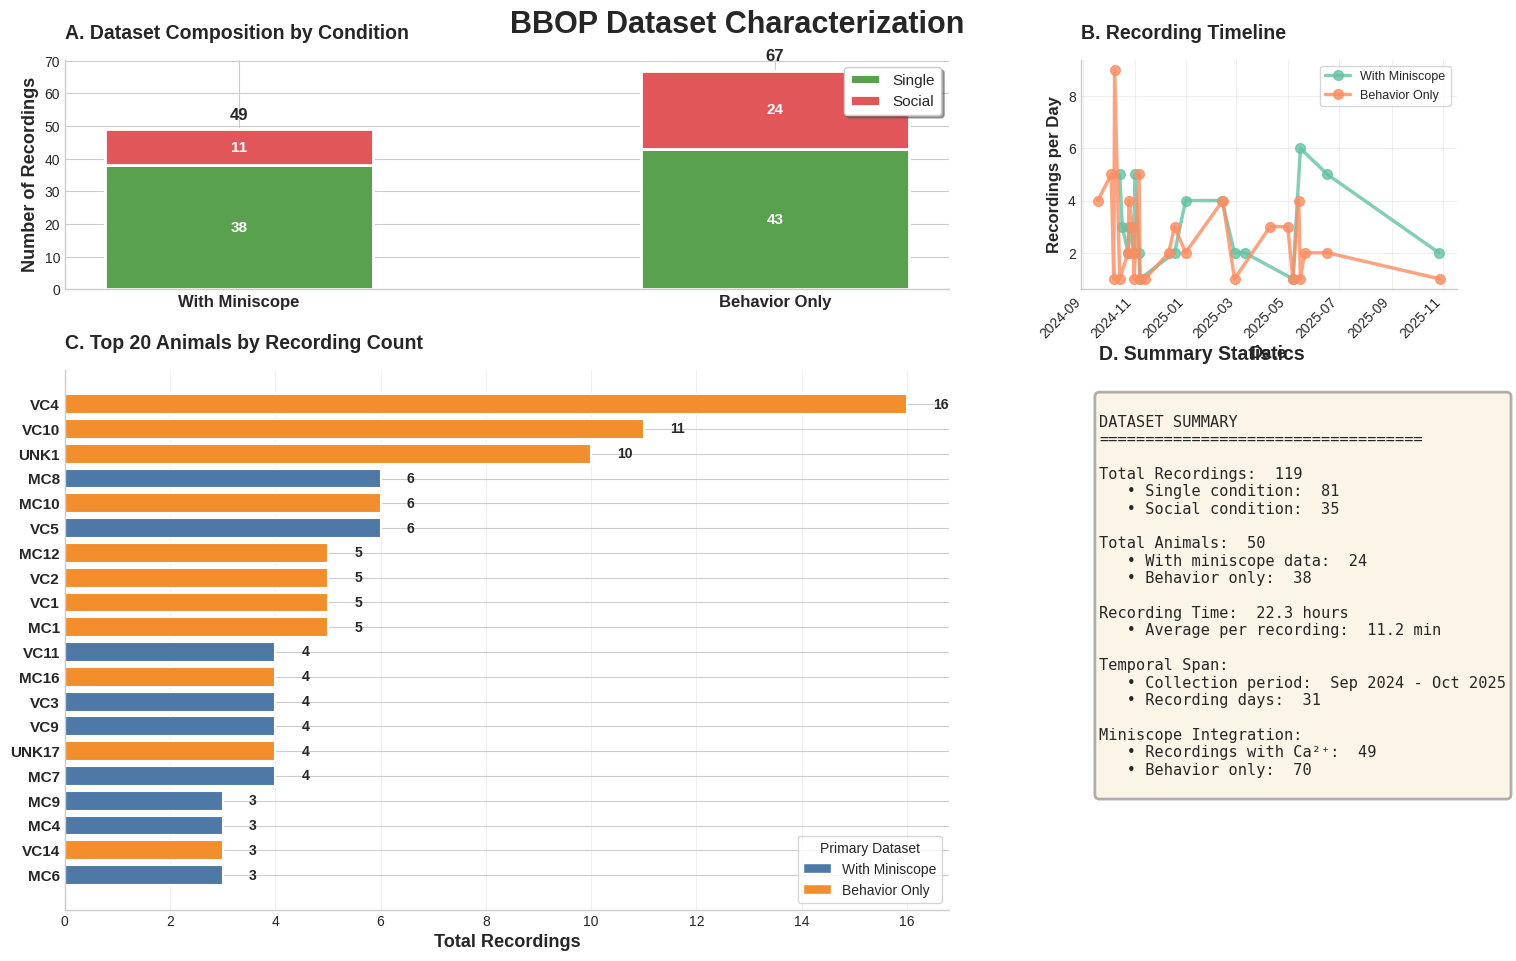

In [ ]:
"""
POSTER-QUALITY DATASET FIGURE
==============================
A single, publication-ready multi-panel figure characterizing the BBOP dataset.
Can be run as a standalone script or pasted into a Jupyter notebook cell.

Usage:
    python poster_figure.py
    OR paste into Jupyter cell and run
"""

import os
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import numpy as np
from datetime import datetime

# ============================================================================
# CONFIGURATION
# ============================================================================

# Output directory - CHANGE THIS TO WHERE YOU WANT FILES SAVED
OUTPUT_DIR = "/home/lq53/mir_repos/BBOP/random_tests/25Sep_posters/dataset_analysis"
# "/hpc/group/tdunn/lq53/BBOP/25oct_sorted_scan/dataset_analysis"

# Add as many datasets as you want here - just add more tuples to the list
DATASETS = [
    ("/data/big_rim/uploade_ssh_mir_dataset/oct3v1_social_mini", "With Miniscope"),
    ("/data/big_rim/uploade_ssh_mir_dataset/oct3v1_beh_only", "Behavior Only"),
    # Add more datasets here in the future:
    # ("/path/to/dataset3", "Dataset 3 Description"),
    # ("/path/to/dataset4", "Dataset 4 Description"),
]

# ============================================================================
# DATA COLLECTION FUNCTIONS
# ============================================================================

def get_recording_duration(rec_path):
    """Extract totalTime from videos/Camera6/metadata.csv"""
    metadata_path = os.path.join(rec_path, 'videos', 'Camera6', 'metadata.csv')
    
    if not os.path.exists(metadata_path):
        return None
    
    try:
        df = pd.read_csv(metadata_path)
        if 'totalTime' in df.columns:
            return float(df['totalTime'].iloc[0])
        else:
            for idx, row in df.iterrows():
                if 'totalTime' in str(row.values):
                    for val in row.values:
                        try:
                            return float(val)
                        except:
                            continue
        return None
    except:
        return None

def analyze_dataset(base_path, dataset_name):
    """Analyze dataset structure and return statistics"""
    
    stats = {
        'dataset_name': dataset_name,
        'base_path': base_path,
        'conditions': {},
        'total_recordings': 0,
        'animals': set(),
        'dates': set(),
        'recordings_by_animal': Counter(),
        'has_miniscope': [],
        'recording_details': [],
        'total_duration_seconds': 0,
        'recordings_with_duration': 0,
    }
    
    if not os.path.exists(base_path):
        print(f"Warning: {base_path} does not exist")
        return stats
    
    for condition in os.listdir(base_path):
        condition_path = os.path.join(base_path, condition)
        if not os.path.isdir(condition_path):
            continue
            
        recordings = [r for r in os.listdir(condition_path) 
                     if os.path.isdir(os.path.join(condition_path, r))]
        stats['conditions'][condition] = len(recordings)
        
        for rec_name in recordings:
            rec_path = os.path.join(condition_path, rec_name)
            stats['total_recordings'] += 1
            
            has_mini = os.path.exists(os.path.join(rec_path, 'miniscope'))
            stats['has_miniscope'].append(has_mini)
            
            duration = get_recording_duration(rec_path)
            if duration is not None:
                stats['total_duration_seconds'] += duration
                stats['recordings_with_duration'] += 1
            
            parts = rec_name.split('_')
            date = None
            animals_in_rec = []
            
            for part in parts:
                if part.isdigit() and len(part) == 8:
                    date = part
                    stats['dates'].add(date)
                
                if '+' in part:
                    animals_in_rec = part.split('+')
                    stats['animals'].update(animals_in_rec)
                    for animal in animals_in_rec:
                        stats['recordings_by_animal'][animal] += 1
                elif any(part.startswith(prefix) for prefix in ['MC', 'VC', 'UNK']):
                    animals_in_rec.append(part)
                    stats['animals'].add(part)
                    stats['recordings_by_animal'][part] += 1
            
            stats['recording_details'].append({
                'name': rec_name,
                'condition': condition,
                'date': date,
                'animals': animals_in_rec,
                'has_miniscope': has_mini,
                'duration_seconds': duration,
            })
    
    return stats

# ============================================================================
# ANALYZE DATA
# ============================================================================

print("Analyzing datasets...")
all_stats = []
all_animals_combined = set()
all_dates_combined = set()

for base_path, name in DATASETS:
    stats = analyze_dataset(base_path, name)
    all_stats.append(stats)
    all_animals_combined.update(stats['animals'])
    all_dates_combined.update(stats['dates'])

print(f"Found {len(all_stats)} datasets")
print(f"Total unique animals: {len(all_animals_combined)}")
print(f"Total recordings: {sum(s['total_recordings'] for s in all_stats)}")

# ============================================================================
# CREATE POSTER FIGURE
# ============================================================================

print("\nCreating poster figure...")

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Create figure with custom layout
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.35,
              left=0.08, right=0.95, top=0.93, bottom=0.08)

# Main title
fig.suptitle('BBOP Dataset Characterization', 
             fontsize=22, fontweight='bold', y=0.98)

# Color scheme
colors = {
    'With Miniscope': '#4E79A7',
    'Behavior Only': '#F28E2B',
    'single': '#59A14F',
    'social': '#E15759',
}

# ============================================================================
# PANEL A: Dataset Composition (stacked bars)
# ============================================================================

ax_a = fig.add_subplot(gs[0, :2])

dataset_names = [s['dataset_name'] for s in all_stats]
single_counts = [s['conditions'].get('single', 0) for s in all_stats]
social_counts = [s['conditions'].get('social', 0) for s in all_stats]

x = np.arange(len(dataset_names))
width = 0.5

bars1 = ax_a.bar(x, single_counts, width, label='Single', 
                 color=colors['single'], edgecolor='white', linewidth=2)
bars2 = ax_a.bar(x, social_counts, width, bottom=single_counts,
                 label='Social', color=colors['social'], edgecolor='white', linewidth=2)

ax_a.set_ylabel('Number of Recordings', fontsize=13, fontweight='bold')
ax_a.set_title('A. Dataset Composition by Condition', 
               fontsize=14, fontweight='bold', loc='left', pad=15)
ax_a.set_xticks(x)
ax_a.set_xticklabels(dataset_names, fontsize=12, fontweight='bold')
ax_a.legend(loc='upper right', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# Add value labels
for i, (s1, s2) in enumerate(zip(single_counts, social_counts)):
    total = s1 + s2
    ax_a.text(i, total + 2, str(total), ha='center', va='bottom', 
             fontweight='bold', fontsize=12)
    if s1 > 5:
        ax_a.text(i, s1/2, str(s1), ha='center', va='center', 
                 fontweight='bold', fontsize=11, color='white')
    if s2 > 5:
        ax_a.text(i, s1 + s2/2, str(s2), ha='center', va='center', 
                 fontweight='bold', fontsize=11, color='white')

# ============================================================================
# PANEL B: Recording Timeline
# ============================================================================

ax_b = fig.add_subplot(gs[0, 2])

# Collect recordings by date for each dataset
date_data = []
for stats in all_stats:
    for rec in stats['recording_details']:
        if rec['date']:
            date_data.append({
                'date': rec['date'],
                'dataset': stats['dataset_name']
            })

df_dates = pd.DataFrame(date_data)
if len(df_dates) > 0:
    df_dates['date'] = pd.to_datetime(df_dates['date'], format='%Y%m%d')
    
    for dataset_name in dataset_names:
        subset = df_dates[df_dates['dataset'] == dataset_name]
        date_counts = subset.groupby('date').size().reset_index(name='count')
        date_counts = date_counts.sort_values('date')
        
        ax_b.plot(date_counts['date'], date_counts['count'], 
                 marker='o', linewidth=2.5, markersize=7,
                 label=dataset_name, alpha=0.8)

ax_b.set_xlabel('Date', fontsize=12, fontweight='bold')
ax_b.set_ylabel('Recordings per Day', fontsize=12, fontweight='bold')
ax_b.set_title('B. Recording Timeline', 
              fontsize=14, fontweight='bold', loc='left', pad=15)
ax_b.legend(loc='best', fontsize=9, frameon=True)
ax_b.grid(True, alpha=0.3)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ============================================================================
# PANEL C: Top Animals by Recording Count
# ============================================================================

ax_c = fig.add_subplot(gs[1:, :2])

# Get top animals across all datasets
all_animal_recordings = {}
animal_dataset_map = {}  # Track which dataset each animal is primarily in

for animal in all_animals_combined:
    total_recs = 0
    dataset_counts = {}
    for stats in all_stats:
        count = stats['recordings_by_animal'].get(animal, 0)
        total_recs += count
        if count > 0:
            dataset_counts[stats['dataset_name']] = count
    
    all_animal_recordings[animal] = total_recs
    # Assign to dataset with most recordings
    if dataset_counts:
        animal_dataset_map[animal] = max(dataset_counts.items(), key=lambda x: x[1])[0]

# Get top 20 animals
top_animals = sorted(all_animal_recordings.items(), key=lambda x: x[1], reverse=True)[:20]
animals = [a[0] for a in top_animals]
counts = [a[1] for a in top_animals]

# Color by dataset
bar_colors = [colors[animal_dataset_map.get(animal, 'Behavior Only')] for animal in animals]

bars = ax_c.barh(range(len(animals)), counts, color=bar_colors, 
                 edgecolor='white', linewidth=1.5)
ax_c.set_yticks(range(len(animals)))
ax_c.set_yticklabels(animals, fontsize=11, fontweight='bold')
ax_c.set_xlabel('Total Recordings', fontsize=13, fontweight='bold')
ax_c.set_title('C. Top 20 Animals by Recording Count', 
              fontsize=14, fontweight='bold', loc='left', pad=15)
ax_c.invert_yaxis()
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax_c.text(count + 0.5, i, str(count), va='center', 
             fontweight='bold', fontsize=10)

# Add legend for colors
legend_elements = [mpatches.Patch(facecolor=colors['With Miniscope'], 
                                  label='With Miniscope', edgecolor='white'),
                   mpatches.Patch(facecolor=colors['Behavior Only'], 
                                  label='Behavior Only', edgecolor='white')]
ax_c.legend(handles=legend_elements, loc='lower right', 
           fontsize=10, frameon=True, title='Primary Dataset')

# ============================================================================
# PANEL D: Summary Statistics
# ============================================================================

ax_d = fig.add_subplot(gs[1:, 2])
ax_d.axis('off')

# Calculate summary statistics
total_recordings = sum(s['total_recordings'] for s in all_stats)
total_animals = len(all_animals_combined)
total_single = sum(s['conditions'].get('single', 0) for s in all_stats)
total_social = sum(s['conditions'].get('social', 0) for s in all_stats)
total_with_mini = sum(sum(s['has_miniscope']) for s in all_stats)
total_duration_hours = sum(s['total_duration_seconds'] for s in all_stats) / 3600
total_dates = len(all_dates_combined)

# Date range
all_dates_sorted = sorted(all_dates_combined)
date_range_str = ""
if all_dates_sorted:
    first_date = datetime.strptime(all_dates_sorted[0], '%Y%m%d').strftime('%b %Y')
    last_date = datetime.strptime(all_dates_sorted[-1], '%Y%m%d').strftime('%b %Y')
    date_range_str = f"{first_date} - {last_date}"

# Create text summary with nice formatting
summary_text = f"""
DATASET SUMMARY
{'='*35}

Total Recordings:  {total_recordings}
   • Single condition:  {total_single}
   • Social condition:  {total_social}

Total Animals:  {total_animals}
   • With miniscope data:  {sum(1 for s in all_stats if s['dataset_name'] == 'With Miniscope' for _ in s['animals'])}
   • Behavior only:  {sum(1 for s in all_stats if s['dataset_name'] == 'Behavior Only' for _ in s['animals'])}

Recording Time:  {total_duration_hours:.1f} hours
   • Average per recording:  {total_duration_hours*60/total_recordings:.1f} min

Temporal Span:
   • Collection period:  {date_range_str}
   • Recording days:  {total_dates}

Miniscope Integration:
   • Recordings with Ca²⁺:  {total_with_mini}
   • Behavior only:  {total_recordings - total_with_mini}
"""

ax_d.text(0.05, 0.95, summary_text, transform=ax_d.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3, 
                  edgecolor='black', linewidth=2))

ax_d.set_title('D. Summary Statistics', 
              fontsize=14, fontweight='bold', loc='left', 
              pad=15, x=0.05, y=0.98)

# ============================================================================
# FINALIZE AND SAVE
# ============================================================================
OUTPUT_FILE = os.path.join(OUTPUT_DIR, 'bbop_dataset_characterization_poster_figure.png')
plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n✓ Poster figure saved to: {OUTPUT_FILE}")
print(f"  Resolution: 300 DPI")
print(f"  Size: 16\" x 10\"")
print(f"  Format: PNG with white background")

plt.show()

print("\n" + "="*60)
print("DONE! Figure ready for poster inclusion.")
print("="*60)